In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates
import warnings 

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("Sample - Superstore.csv",encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


### EDA and Data Cleaning


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
print("Categories :", df["Category"].unique())
print("Regions    :", df["Region"].unique())
print("Sub-cats   :", df["Sub-Category"].nunique())

Categories : ['Furniture' 'Office Supplies' 'Technology']
Regions    : ['South' 'West' 'Central' 'East']
Sub-cats   : 17


In [9]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [10]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Order Date']

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[ns]

In [11]:
print("Date range:")
print(" From:", df["Order Date"].min())
print(" To  :", df["Order Date"].max())

Date range:
 From: 2014-01-03 00:00:00
 To  : 2017-12-30 00:00:00


In [12]:
df['Sales'].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

In [13]:
dfe = df[['Order Date','Segment','Region','Category','Sub-Category','Sales','Quantity','Discount','Profit']].copy()

print("Shape:", dfe.shape)
print("\nColumn dtypes:")
print(dfe.dtypes)
dfe.head()

Shape: (9994, 9)

Column dtypes:
Order Date      datetime64[ns]
Segment                 object
Region                  object
Category                object
Sub-Category            object
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object


,Order Date,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [14]:
dfe.set_index(['Order Date'],inplace=True)
dfe.head()

,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,
2016-11-08,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
2016-11-08,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2016-06-12,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
2015-10-11,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310
2015-10-11,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


<Axes: xlabel='Order Date'>

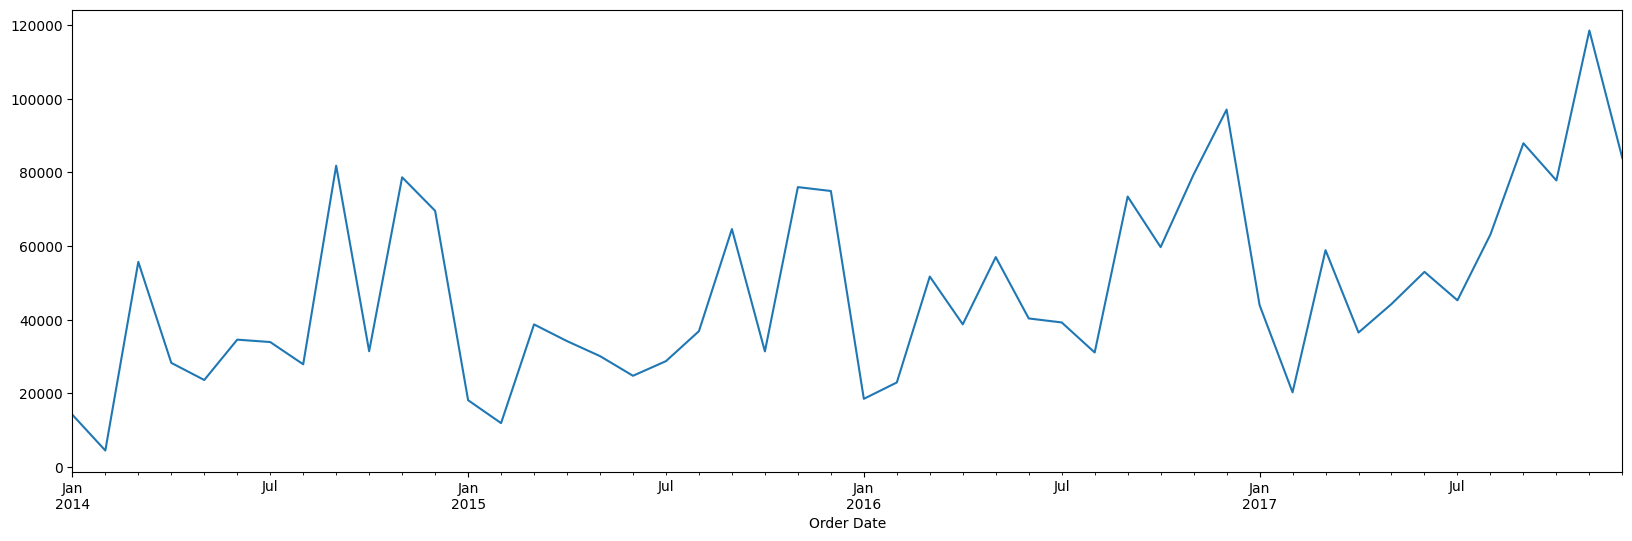

In [15]:
# %matplotlib inline
plt.figure(figsize=(20,6))
dfe.Sales.resample('ME').sum().plot()

In [16]:
monthly = dfe['Sales'].resample('ME').sum().reset_index()
monthly.columns = ['ds', 'y']

print("Shape:", monthly.shape)
print("Date range:", monthly['ds'].min().date(), "→", monthly['ds'].max().date())
monthly.head()

Shape: (48, 2)
Date range: 2014-01-31 → 2017-12-31


,ds,y
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


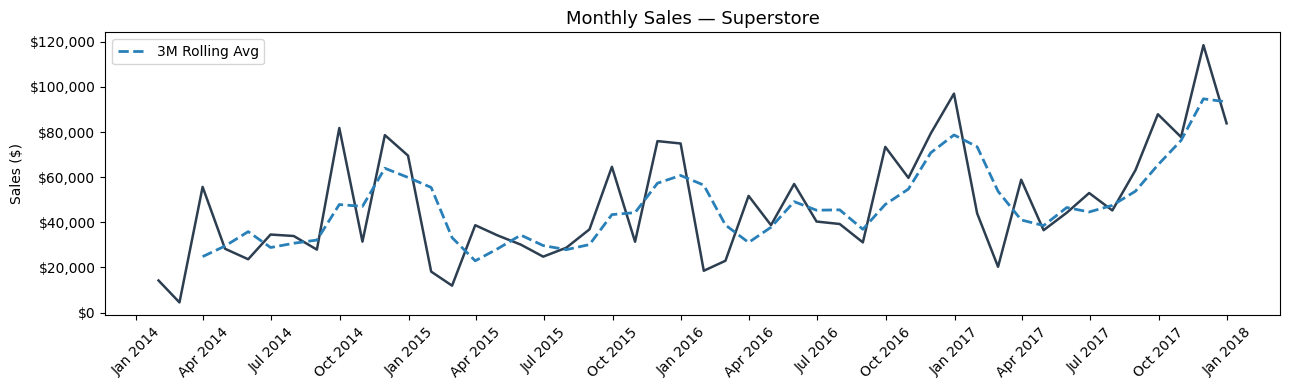

In [17]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['ds'], monthly['y'], color='#2C3E50', linewidth=1.8)
ax.plot(monthly['ds'], monthly['y'].rolling(3).mean(),
        color='#2980B9', linewidth=2, linestyle='--', label='3M Rolling Avg')
ax.set_title('Monthly Sales — Superstore', fontsize=13)
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
!pip install statsmodels -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


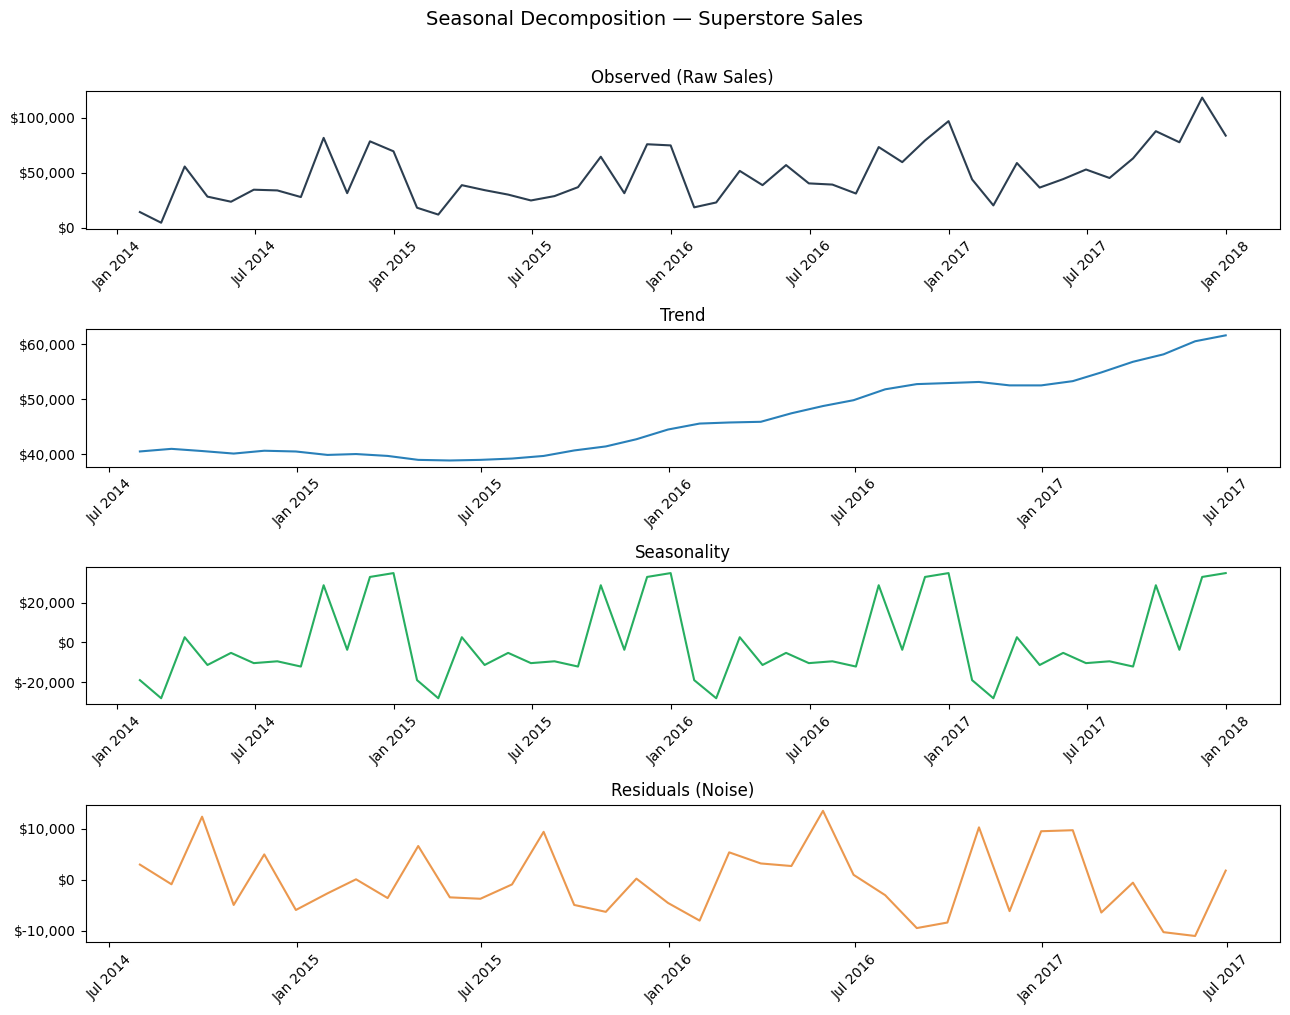

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set ds as index for statsmodels
ts = monthly.set_index('ds')['y']

# period=12 because we have monthly data with yearly seasonality
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))

axes[0].plot(decomp.observed,  color='#2C3E50'); axes[0].set_title('Observed (Raw Sales)')
axes[1].plot(decomp.trend,     color='#2980B9'); axes[1].set_title('Trend')
axes[2].plot(decomp.seasonal,  color='#27AE60'); axes[2].set_title('Seasonality')
axes[3].plot(decomp.resid,     color='#E67E22', alpha=0.8); axes[3].set_title('Residuals (Noise)')

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.suptitle('Seasonal Decomposition — Superstore Sales', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### ADF Stationary Test

In [20]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.dropna())

print('─' * 40)
print('ADF Stationarity Test')
print('─' * 40)
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Critical Values:')
for key, val in result[4].items():
    print(f'   {key}  :  {val:.4f}')
print('─' * 40)

if result[1] < 0.05:
    print('Series is STATIONARY (p < 0.05)')
    print('d=0 in SARIMA — no differencing needed')
else:
    print('Series is NON-STATIONARY (p > 0.05)')
    print('d=1 in SARIMA — first differencing needed')

────────────────────────────────────────
ADF Stationarity Test
────────────────────────────────────────
ADF Statistic : -4.4938
p-value       : 0.0002
Critical Values:
   1%  :  -3.5778
   5%  :  -2.9253
   10%  :  -2.6008
────────────────────────────────────────
Series is STATIONARY (p < 0.05)
d=0 in SARIMA — no differencing needed


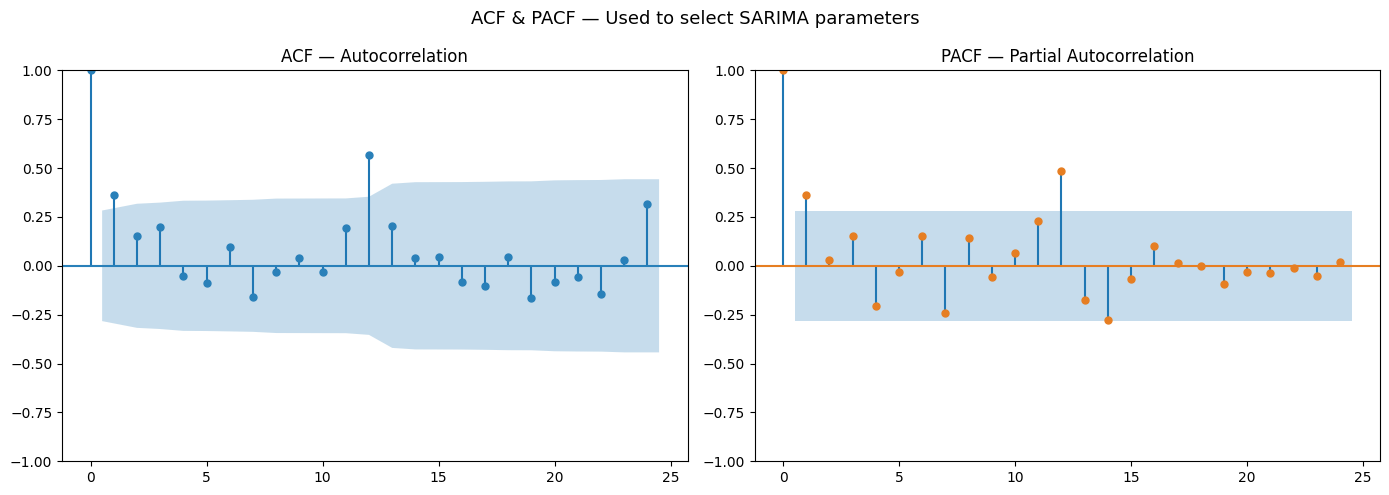

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ts.dropna(),  lags=24, ax=axes[0], color='#2980B9')
axes[0].set_title('ACF — Autocorrelation')

plot_pacf(ts.dropna(), lags=24, ax=axes[1], color='#E67E22')
axes[1].set_title('PACF — Partial Autocorrelation')

plt.suptitle('ACF & PACF — Used to select SARIMA parameters', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# Split — train on 2014-2016, test on 2017
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_ts = ts[ts.index < '2017-07-01']
test_ts  = ts[ts.index >= '2017-07-01']

print(f"Train : {len(train_ts)} months ({train_ts.index.min().date()} → {train_ts.index.max().date()})")
print(f"Test  : {len(test_ts)} months ({test_ts.index.min().date()} → {test_ts.index.max().date()})")

# Fit SARIMA on train only
model_eval = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_eval = model_eval.fit(disp=False)
print("\n SARIMA fitted on training data")

Train : 42 months (2014-01-31 → 2017-06-30)
Test  : 6 months (2017-07-31 → 2017-12-31)

 SARIMA fitted on training data


C:\Users\Shoaib Nisar\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Shoaib Nisar\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [23]:
# Predict exactly as many months as the test set
predictions = result_eval.get_forecast(steps=len(test_ts))
pred_mean   = predictions.predicted_mean
pred_ci     = predictions.conf_int()

# Align index to match test set dates
pred_mean.index = test_ts.index
pred_ci.index   = test_ts.index

print("Actual vs Predicted — 2017(last 6 Months):")
eval_df = pd.DataFrame({
    'Month'    : test_ts.index.strftime('%B %Y'),
    'Actual'   : test_ts.values.round(0),
    'Predicted': pred_mean.values.round(0),
    'Error'    : (test_ts.values - pred_mean.values).round(0)
})
print(eval_df.to_string(index=False))

Actual vs Predicted — 2017(last 6 Months):
         Month   Actual  Predicted    Error
     July 2017  45264.0    47969.0  -2704.0
   August 2017  63121.0    45452.0  17669.0
September 2017  87867.0    82801.0   5066.0
  October 2017  77777.0    60085.0  17692.0
 November 2017 118448.0    89772.0  28676.0
 December 2017  83829.0    98693.0 -14864.0


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

actual    = test_ts.values
predicted = pred_mean.values

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
smape = np.mean(2 * np.abs(actual - predicted) / 
                (np.abs(actual) + np.abs(predicted))) * 100

naive_mape = np.mean(np.abs(
    (actual - train_ts.tail(12).values[:len(test_ts)]) / actual
)) * 100

print('─' * 50)
print('  SARIMA — Model Evaluation')
print(f'  Train : {len(train_ts)} months | Test : {len(test_ts)} months')
print('─' * 50)
print(f'  MAE   : ${mae:>10,.0f}')
print(f'         "Forecast is off by ${mae:,.0f} per month on average"')
print()
print(f'  RMSE  : ${rmse:>10,.0f}')
print(f'         "Large errors penalised more — ${rmse:,.0f}"')
print()
print(f'  MAPE  : {mape:>9.1f}%')
print(f'         "Forecast is off by {mape:.1f}% on average"')
print()
print(f'  SMAPE : {smape:>9.1f}%')
print(f'         "Symmetric MAPE — {smape:.1f}%"')
print('─' * 50)
print(f'  Naive baseline MAPE : {naive_mape:.1f}%')
if mape < naive_mape:
    print(f'Beats naive by {naive_mape - mape:.1f}%')
else:
    print(f'Does not beat naive baseline')
print('─' * 50)

──────────────────────────────────────────────────
  SARIMA — Model Evaluation
  Train : 42 months | Test : 6 months
──────────────────────────────────────────────────
  MAE   : $    14,445
         "Forecast is off by $14,445 per month on average"

  RMSE  : $    16,839
         "Large errors penalised more — $16,839"

  MAPE  :      17.4%
         "Forecast is off by 17.4% on average"

  SMAPE :      19.0%
         "Symmetric MAPE — 19.0%"
──────────────────────────────────────────────────
  Naive baseline MAPE : 25.4%
Beats naive by 8.0%
──────────────────────────────────────────────────


RMSE: 16839.44


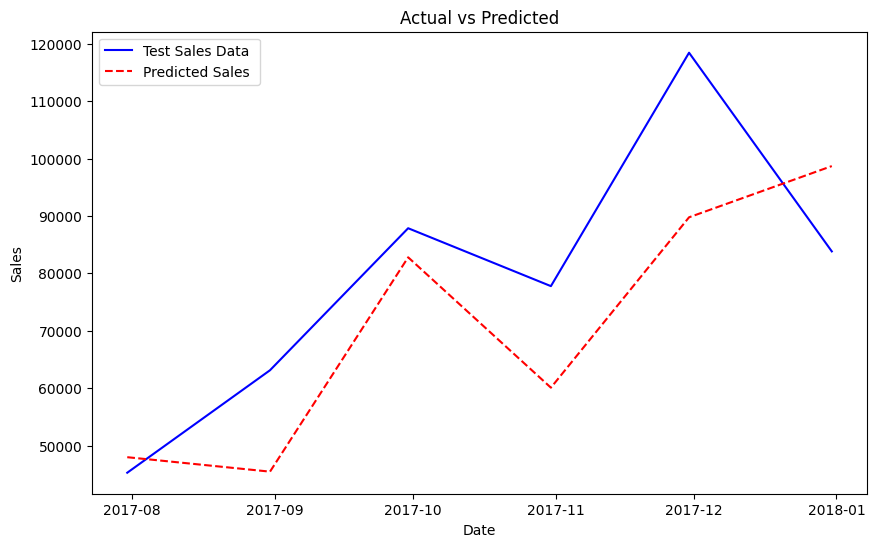

In [25]:
from sklearn.metrics import mean_squared_error

plt.figure(figsize=(10,6))
plt.plot(test_ts.index, test_ts, color='blue' , label='Test Sales Data')
plt.plot(test_ts.index, pred_mean , linestyle='--', color='red' ,label='Predicted Sales ')
plt.title('Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
rmse=round(np.sqrt(mean_squared_error(test_ts,pred_mean)),2)
print("RMSE:", rmse)

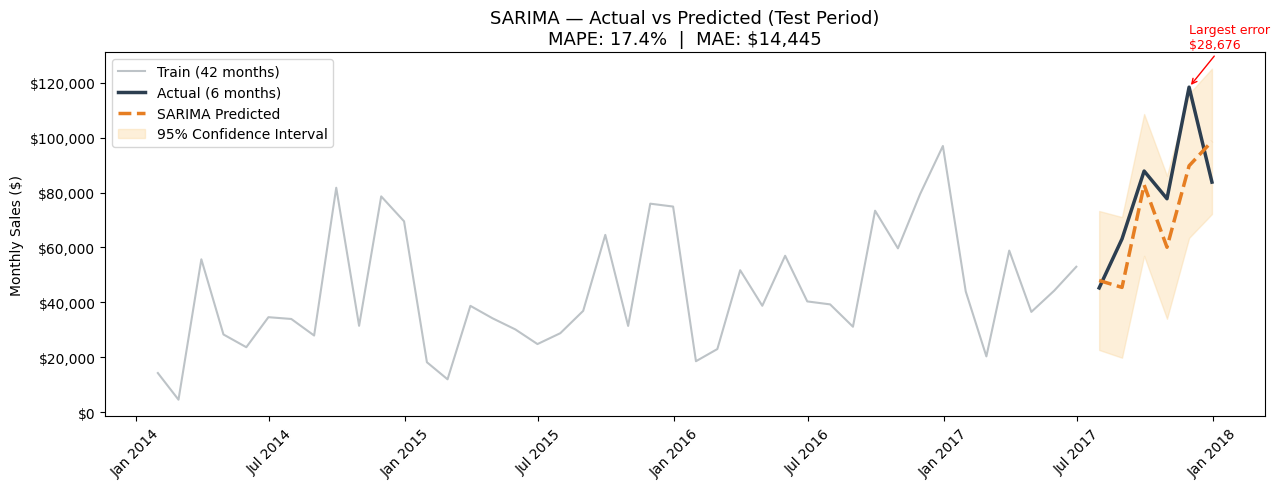

In [26]:
fig, ax = plt.subplots(figsize=(13, 5))

# Full train history in light grey for context
ax.plot(train_ts.index, train_ts.values,
        color='#BDC3C7', linewidth=1.5, label=f'Train ({len(train_ts)} months)')

# Actual test period
ax.plot(test_ts.index, test_ts.values,
        color='#2C3E50', linewidth=2.5, label=f'Actual ({len(test_ts)} months)')

# Predicted test period
ax.plot(test_ts.index, predicted,
        color='#E67E22', linewidth=2.5,
        linestyle='--', label='SARIMA Predicted')

# Confidence interval
pred_ci = pred_mean  # already computed earlier
forecast_ci_eval = result_eval.get_forecast(steps=len(test_ts)).conf_int()
forecast_ci_eval.index = test_ts.index

ax.fill_between(test_ts.index,
                forecast_ci_eval.iloc[:, 0],
                forecast_ci_eval.iloc[:, 1],
                color='#FAD7A0', alpha=0.4,
                label='95% Confidence Interval')

# Highlight worst error month
errors     = np.abs(actual - predicted)
worst_idx  = np.argmax(errors)
worst_date = test_ts.index[worst_idx]

ax.annotate(f'Largest error\n${errors[worst_idx]:,.0f}',
            xy=(worst_date, test_ts.iloc[worst_idx]),
            xytext=(worst_date, test_ts.iloc[worst_idx] * 1.12),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=9)

ax.set_title(f'SARIMA — Actual vs Predicted (Test Period)\n'
             f'MAPE: {mape:.1f}%  |  MAE: ${mae:,.0f}',
             fontsize=13)
ax.set_ylabel('Monthly Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

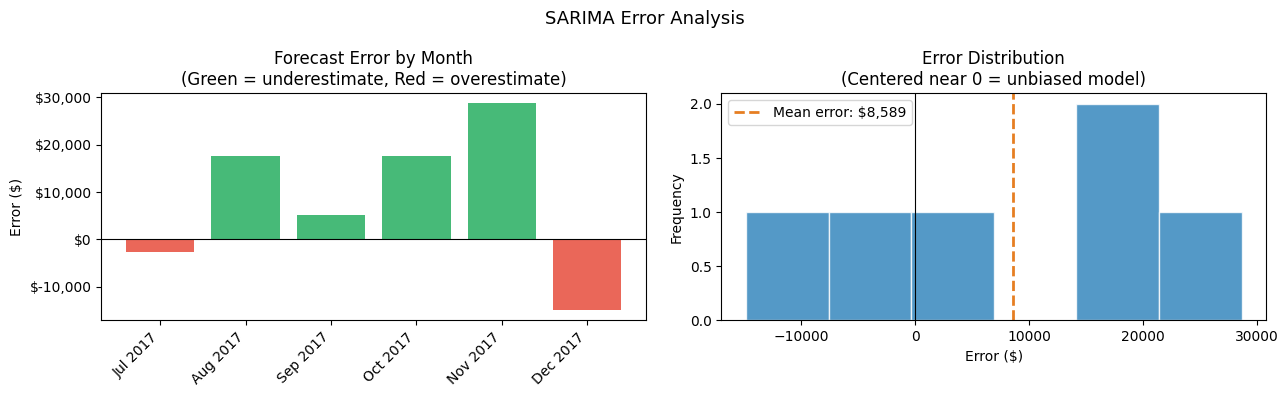

Mean error : $8,589
⚠️  Model has systematic bias — consistently over or under predicting


In [27]:
errors_signed = actual - predicted

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — one bar per test month
axes[0].bar(
    test_ts.index.strftime('%b %Y'),
    errors_signed,
    color=['#27AE60' if e > 0 else '#E74C3C' for e in errors_signed],
    alpha=0.85
)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Forecast Error by Month\n'
                  '(Green = underestimate, Red = overestimate)')
axes[0].set_ylabel('Error ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Histogram
axes[1].hist(errors_signed, bins=6,
             color='#2980B9', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(errors_signed.mean(),
                color='#E67E22', linewidth=2, linestyle='--',
                label=f'Mean error: ${errors_signed.mean():,.0f}')
axes[1].set_title('Error Distribution\n'
                  '(Centered near 0 = unbiased model)')
axes[1].set_xlabel('Error ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('SARIMA Error Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mean error : ${errors_signed.mean():,.0f}')
if abs(errors_signed.mean()) < mae * 0.1:
    print('✅ Model is unbiased — errors cancel out on average')
else:
    print('⚠️  Model has systematic bias — consistently over or under predicting')

In [28]:
# Now retrain on ALL data (train_ts + test_ts combined)
# This gives the best possible forecast for future months

model_final = SARIMAX(
    ts,
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result_final = model_final.fit(disp=False)

print('✅ Final model refitted on complete dataset')
print(f'   Total months used : {len(ts)}')
print(f'   AIC               : {result_final.aic:.2f}')
print(f'   BIC               : {result_final.bic:.2f}')

✅ Final model refitted on complete dataset
   Total months used : 48
   AIC               : 492.13
   BIC               : 495.40


C:\Users\Shoaib Nisar\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Shoaib Nisar\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [29]:
FORECAST_MONTHS = 12

forecast_obj  = result_final.get_forecast(steps=FORECAST_MONTHS)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int()

forecast_df = pd.DataFrame({
    'Month'     : forecast_mean.index.strftime('%B %Y'),
    'Forecast'  : forecast_mean.values.round(0).astype(int),
    'Lower 95%' : forecast_ci.iloc[:, 0].values.round(0).astype(int),
    'Upper 95%' : forecast_ci.iloc[:, 1].values.round(0).astype(int)
})

print('─' * 60)
print('  12-Month Sales Forecast')
print('─' * 60)
print(forecast_df.to_string(index=False))
print('─' * 60)
print(f'  Total forecast : ${forecast_mean.sum():>12,.0f}')
print(f'  Monthly avg    : ${forecast_mean.mean():>12,.0f}')
print('─' * 60)

────────────────────────────────────────────────────────────
  12-Month Sales Forecast
────────────────────────────────────────────────────────────
         Month  Forecast  Lower 95%  Upper 95%
  January 2018     53297      23146      83448
 February 2018     31070      -1609      63749
    March 2018     72428      32572     112283
    April 2018     50489       7210      93769
      May 2018     66859      19042     114676
     June 2018     59857       8651     111062
     July 2018     56774       1985     111562
   August 2018     59628       1701     117555
September 2018     94447      33420     155474
  October 2018     82152      18243     146061
 November 2018    111290      44586     177995
 December 2018    105621      36256     174987
────────────────────────────────────────────────────────────
  Total forecast : $     843,911
  Monthly avg    : $      70,326
────────────────────────────────────────────────────────────


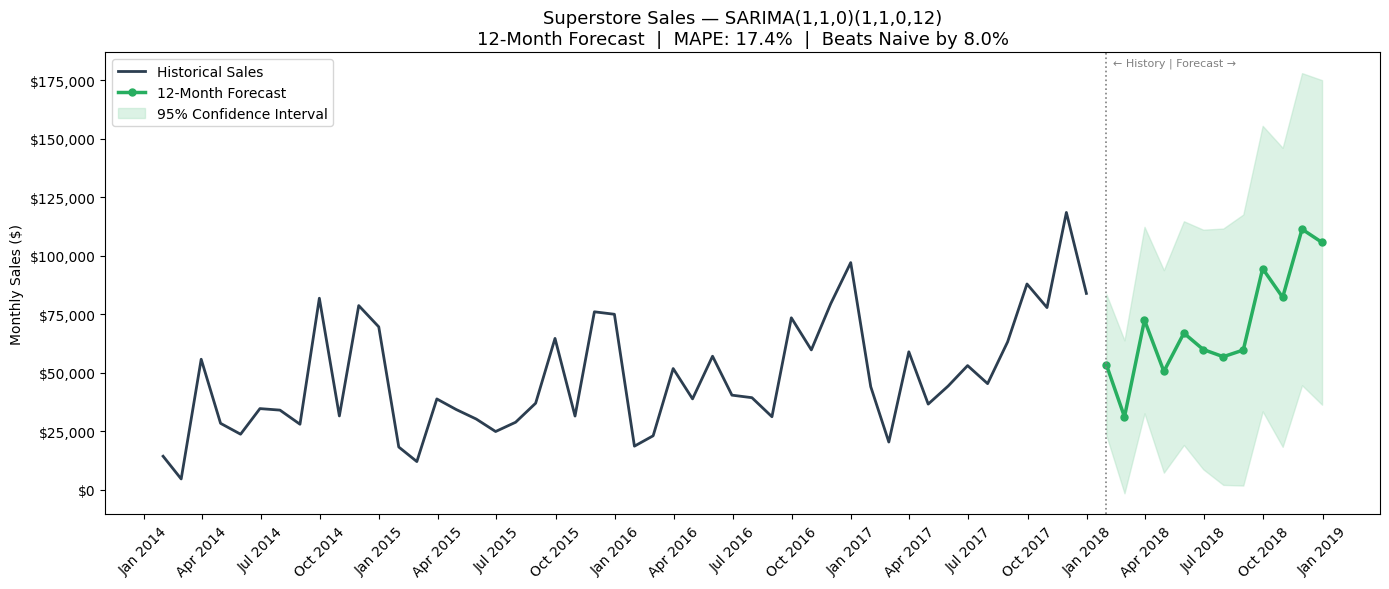

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

# Full historical
ax.plot(ts.index, ts.values,
        color='#2C3E50', linewidth=2,
        label='Historical Sales')

# Forecast
ax.plot(forecast_mean.index, forecast_mean.values,
        color='#27AE60', linewidth=2.5,
        marker='o', markersize=5,
        label='12-Month Forecast')

# Confidence band
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='#A9DFBF', alpha=0.4,
                label='95% Confidence Interval')

# Divider
ax.axvline(x=forecast_mean.index[0],
           color='grey', linestyle=':', linewidth=1.2)
ax.text(forecast_mean.index[0],
        ax.get_ylim()[1] * 0.97,
        '  ← History | Forecast →',
        fontsize=8, color='grey')

ax.set_title('Superstore Sales — SARIMA(1,1,0)(1,1,0,12)\n'
             f'12-Month Forecast  |  MAPE: {mape:.1f}%  |  '
             f'Beats Naive by {naive_mape - mape:.1f}%',
             fontsize=13)
ax.set_ylabel('Monthly Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
total   = forecast_mean.sum()
peak    = forecast_mean.idxmax()
trough  = forecast_mean.idxmin()
last_12 = ts.tail(12).sum()
yoy     = (total - last_12) / last_12 * 100

print('═' * 52)
print('   SALES FORECAST REPORT — BUSINESS SUMMARY')
print('═' * 52)
print(f'  Model        : SARIMA(1,1,0)(1,1,0,12)')
print(f'  Train months : {len(train_ts)}')
print(f'  Test months  : {len(test_ts)}')
print(f'  MAPE         : {mape:.1f}%  (±${mae:,.0f}/month avg error)')
print(f'  vs Naive     : ✅ better by {naive_mape - mape:.1f}%')
print('─' * 52)
print(f'  Total forecast (next 12M) : ${total:>12,.0f}')
print(f'  Last 12 months (actual)   : ${last_12:>12,.0f}')
print(f'  Year-over-year change     : {yoy:>+10.1f}%')
print('─' * 52)
print(f'  Peak month    : {peak.strftime("%B %Y")}'
      f'   →  ${forecast_mean[peak]:>10,.0f}')
print(f'  Slowest month : {trough.strftime("%B %Y")}'
      f'   →  ${forecast_mean[trough]:>10,.0f}')
print('═' * 52)
print('  RECOMMENDATIONS')
print('═' * 52)
print(f'  • Stock up before {peak.strftime("%B")} — highest demand month')
print(f'  • Reduce orders in {trough.strftime("%B")} — slowest month')
print(f'  • Budget ~${total/12:,.0f}/month on average next year')
print(f'  • Use 3-month forecast for operations,')
print(f'    12-month for strategic planning only')
print(f'  • Rerun monthly as new sales data comes in')
print('═' * 52)

════════════════════════════════════════════════════
   SALES FORECAST REPORT — BUSINESS SUMMARY
════════════════════════════════════════════════════
  Model        : SARIMA(1,1,0)(1,1,0,12)
  Train months : 42
  Test months  : 6
  MAPE         : 17.4%  (±$14,445/month avg error)
  vs Naive     : ✅ better by 8.0%
────────────────────────────────────────────────────
  Total forecast (next 12M) : $     843,911
  Last 12 months (actual)   : $     733,215
  Year-over-year change     :      +15.1%
────────────────────────────────────────────────────
  Peak month    : November 2018   →  $   111,290
  Slowest month : February 2018   →  $    31,070
════════════════════════════════════════════════════
  RECOMMENDATIONS
════════════════════════════════════════════════════
  • Stock up before November — highest demand month
  • Reduce orders in February — slowest month
  • Budget ~$70,326/month on average next year
  • Use 3-month forecast for operations,
    12-month for strategic planning only
